# HMP

In [1]:
import numpy as np
import mne
import hmp
import os
import xarray as xr

from pathlib import Path
from mne.io import read_info


In [2]:
# map waar je fif bestanden staan
epoch_data_path = r"C:\Master Thesis BDS\data\preprocessed"


# alle epochs files zoeken
subj_files = [
    os.path.join(epoch_data_path, f)
    for f in os.listdir(epoch_data_path)
    if f.endswith("_epo.fif")
]


# subject namen halen
subj_names = [
    os.path.splitext(os.path.basename(f))[0]
    for f in subj_files
]


print(len(subj_files))
print(subj_files[:3])
print(subj_names[:3])


# channel informatie
info = read_info(
    subj_files[0],
    verbose=False
)


# sampling frequency
sfreq = 256 

# HMP dataset maken
epoch_data = hmp.io.read_mne_data(
    subj_files,
    data_format="epochs",
    sfreq=sfreq,
    verbose=False,
    subj_name=subj_names
)

print(epoch_data)

27
['C:\\Master Thesis BDS\\data\\preprocessed\\sub-LTP063_ses-0_epo.fif', 'C:\\Master Thesis BDS\\data\\preprocessed\\sub-LTP063_ses-10_epo.fif', 'C:\\Master Thesis BDS\\data\\preprocessed\\sub-LTP063_ses-11_epo.fif']
['sub-LTP063_ses-0_epo', 'sub-LTP063_ses-10_epo', 'sub-LTP063_ses-11_epo']
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-0_epo.fif's epochs eeg
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-10_epo.fif's epochs eeg
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-11_epo.fif's epochs eeg
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-12_epo.fif's epochs eeg
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-13_epo.fif's epochs eeg
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-14_epo.fif's epochs eeg
Processing participant C:\Master Thesis BDS\data\preprocessed\sub-LTP063_ses-15_epo.fif's epochs eeg


In [ ]:
# PCA preprocessing
preprocessed = hmp.preprocessors.ProjPCA(epoch_data,
                                        min_duration=.2, #Defining minimum reaction time as 200ms 
                                        max_duration=2, # Maximum reaction time at 2s
                                        reject_threshold=1e-4, #Peak-to-peak rejection threshold of 100 microV
                                        interval_id = "RT", #In which variable of epoch_data are the duration to be modelled
                                        n_comp=10, # How many principal components to keep for the fit, the more the better
                                       )

model = hmp.models.CumulativeMethod()

_, estimates = model.fit_transform(
    preprocessed
)

4525 positively defined intervalsbetween 0.2 and 2 seconds.
Rejection summary: 
 447 trials rejected based on threshold of 0.0001 
 0 trials rejected based on interval limit of (0.2, 2) 
 0 trials detected with no interval (e.g. preprocessing or interval exceeding epoch)) 


  0%|          | 0/27 [00:00<?, ?it/s]

1 events found around times [50]
2 events found around times [42, 214]
3 events found around times [42, 214, 675]
4 events found around times [39, 171, 367, 679]
5 events found around times [39, 164, 320, 558, 691]


In [1]:
from mne.io import read_info

hmp.visu.plot_topo_timecourse(epoch_data, estimates, info)

NameError: name 'hmp' is not defined

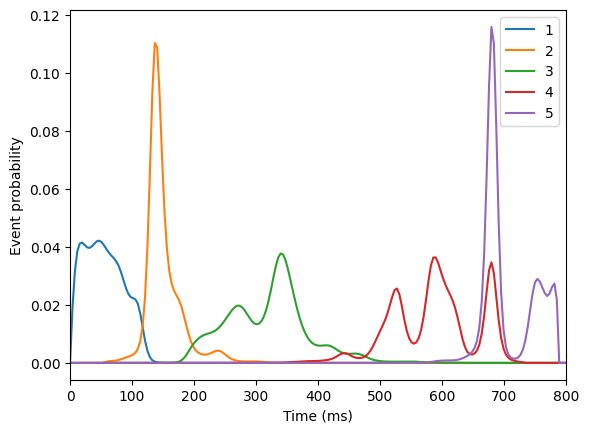

In [7]:
import matplotlib.pyplot as plt
n_events = estimates.sizes['event']
times_ms = estimates.sample.values / 256 * 1000

plt.plot(times_ms, estimates.isel(trial=-1), label=list(range(1, n_events + 1)))
plt.xlim(0, 800)
plt.xlabel('Time (ms)')
plt.ylabel('Event probability')
plt.legend()
plt.show()

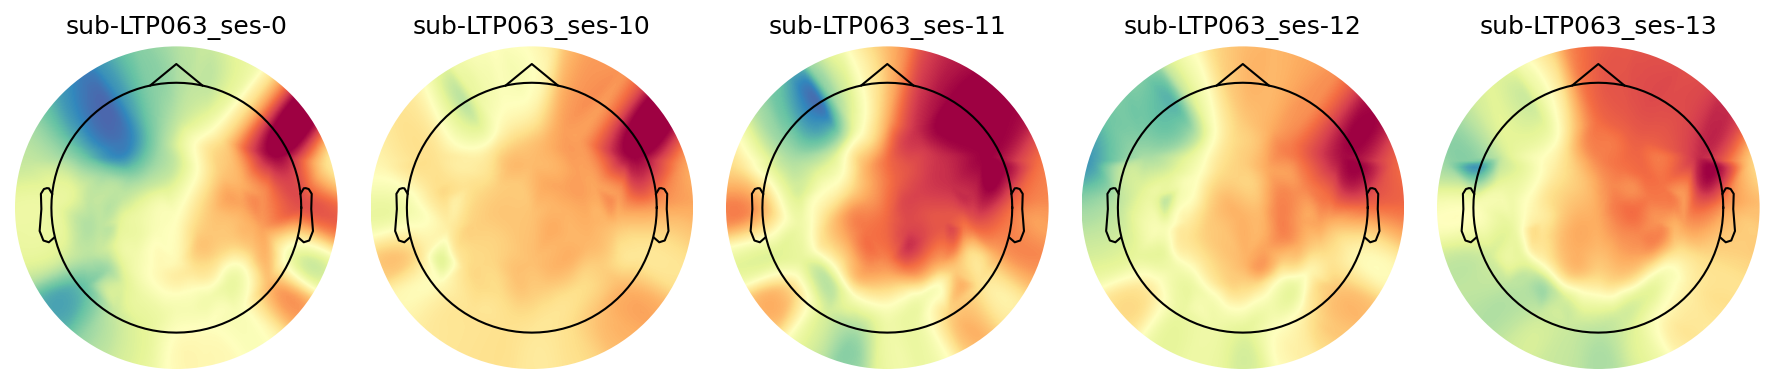

In [9]:
# Plotting individual topographies for a specific event across participants
from mne.viz import plot_topomap

# Get event-channel weights for each trial
by_trial_weights = hmp.utils.event_channels(epoch_data, estimates, mean=False)

# Plot topographies for each participant for a selected event
fig, axes = plt.subplots(1, 5, dpi=150, figsize=(12, 2.5))
axes = axes.flatten()
event = 4 # Event index to plot (1-based for display, 0-based for indexing)

# Looking at the topographies of the 5 first participants
for i, participant in enumerate(epoch_data.participant[:5]):
    ax = axes[i]
    # Average across epochs for the selected event and participant
    topo = by_trial_weights.sel(event=event-1, participant=participant).mean('epoch')
    plot_topomap(
        topo,
        info,
        sensors=False,
        cmap='Spectral_r',
        res=100,
        show=False,
        axes=ax,
        contours=False
    )
    ax.set_title(f'{str(participant.values)[:-4]}')

plt.tight_layout()

In [19]:
# Compute max likely time for each trial and each event
times =  hmp.utils.event_times(estimates, duration=True, add_rt=True)
times

<xarray.DataArray (trial: 4078, event: 6)> Size: 196kB
array([[ 12.,  26.,  46., 354.,  31.,   5.],
       [ 14.,  28.,  91., 166.,  33.,   4.],
       [  9.,  34.,  93., 214.,  18.,  21.],
       ...,
       [  4.,  32.,  36., 111.,  18.,   6.],
       [  7.,  24.,  73.,  96.,  58.,  12.],
       [ 12.,  23.,  52.,  64.,  23.,  28.]], shape=(4078, 6))
Coordinates:
  * trial        (trial) object 33kB MultiIndex
  * participant  (trial) <U21 343kB 'sub-LTP063_ses-0_epo' ... 'sub-LTP065_se...
  * epoch        (trial) int64 33kB 1 17 21 27 31 33 ... 303 304 307 311 313 314
    trial_type   (trial) object 33kB 'RECOG_LURE' 'RECOG_LURE' ... 'RECOG_LURE'
    onset        (trial) float64 33kB 3.863e+03 3.945e+03 ... 4.469e+03
    onset_resp   (trial) float64 33kB 3.865e+03 3.946e+03 ... 4.467e+03 4.47e+03
    RT           (trial) float64 33kB 1.856 1.316 1.524 ... 0.812 1.058 0.792
    correct      (trial) float64 33kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    group        (trial) int8 4kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
  * event        (event) int64 48B 0 1 2 3 4 5
Attributes:
    sfreq:         256.0
    event_width:   13
    likelihood:    -12636.991
    group_lkh:     [-12636.991]
    group_labels:  ('group all', array([['']], dtype=object))

In [20]:
first_channel = epoch_data.channel.values[0]

# Turn into dataframe and recover metadata
times = times.unstack().to_dataframe(name='duration')
times = times[~times.duration.isna()]  #Remove rejected trials
times = times.reset_index().set_index(['participant','epoch'])

# Recover metadata and merge with times
times_metadata = (
    epoch_data
    .sel(sample=0, channel=first_channel)
    .to_dataframe()
    .iloc[:,3:]
)
times_metadata = times_metadata.reset_index().set_index(['participant','epoch'])
times = times.merge(times_metadata, on=['participant','epoch'])

times

event  trial_type_x   onset_x  onset_resp_x  \
participant          epoch                                                
sub-LTP063_ses-0_epo 1          0    RECOG_LURE  3862.794      3864.650   
                     17         0    RECOG_LURE  3945.078      3946.394   
                     21         0    RECOG_LURE  3995.936      3997.460   
                     27         0    RECOG_LURE  4022.738      4024.206   
                     31         0    RECOG_LURE  4039.806      4041.158   
...                           ...           ...       ...           ...   
sub-LTP065_ses-1_epo 304        5    RECOG_LURE  4438.776      4439.482   
                     307        5  RECOG_TARGET  4447.766      4448.436   
                     311        5    RECOG_LURE  4459.858      4460.670   
                     313        5    RECOG_LURE  4465.808      4466.866   
                     314        5    RECOG_LURE  4468.992      4469.784   

                             RT_x  correct_x  group  duration  trial_type_y  \
participant          epoch                                                    
sub-LTP063_ses-0_epo 1      1.856        1.0    0.0      12.0    RECOG_LURE   
                     17     1.316        1.0    0.0      14.0    RECOG_LURE   
                     21     1.524        1.0    0.0       9.0    RECOG_LURE   
                     27     1.468        1.0    0.0       7.0    RECOG_LURE   
                     31     1.352        1.0    0.0       9.0    RECOG_LURE   
...                           ...        ...    ...       ...           ...   
sub-LTP065_ses-1_epo 304    0.706        1.0    0.0      12.0    RECOG_LURE   
                     307    0.670        1.0    0.0       6.0  RECOG_TARGET   
                     311    0.812        1.0    0.0       6.0    RECOG_LURE   
                     313    1.058        1.0    0.0      12.0    RECOG_LURE   
                     314    0.792        1.0    0.0      28.0    RECOG_LURE   

                             onset_y  onset_resp_y   RT_y  correct_y  
participant          epoch                                            
sub-LTP063_ses-0_epo 1      3862.794      3864.650  1.856        1.0  
                     17     3945.078      3946.394  1.316        1.0  
                     21     3995.936      3997.460  1.524        1.0  
                     27     4022.738      4024.206  1.468        1.0  
                     31     4039.806      4041.158  1.352        1.0  
...                              ...           ...    ...        ...  
sub-LTP065_ses-1_epo 304    4438.776      4439.482  0.706        1.0  
                     307    4447.766      4448.436  0.670        1.0  
                     311    4459.858      4460.670  0.812        1.0  
                     313    4465.808      4466.866  1.058        1.0  
                     314    4468.992      4469.784  0.792        1.0  

[24468 rows x 13 columns]

Text(0.5, 1.0, 'Event durations by condition')

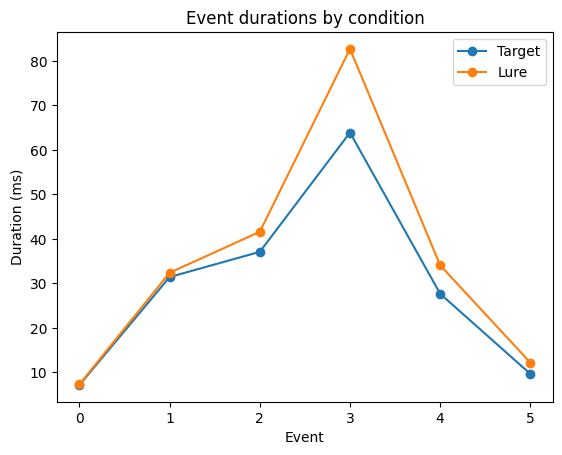

In [24]:
import matplotlib.pyplot as plt
mean_target = (
    times[times["trial_type_x"] == "RECOG_TARGET"]
    .groupby("event")["duration"]
    .mean()
)

mean_lure = (
    times[times["trial_type_x"] == "RECOG_LURE"]
    .groupby("event")["duration"]
    .mean()
)

plt.plot(mean_target.index, mean_target.values, 'o-', label='Target')
plt.plot(mean_lure.index, mean_lure.values, 'o-', label='Lure')
plt.legend()
plt.xlabel('Event')
plt.ylabel('Duration (ms)')
plt.title('Event durations by condition')

In [23]:
print(times.columns)

print(times.head())

Index(['event', 'trial_type_x', 'onset_x', 'onset_resp_x', 'RT_x', 'correct_x',
       'group', 'duration', 'trial_type_y', 'onset_y', 'onset_resp_y', 'RT_y',
       'correct_y'],
      dtype='str')
                            event trial_type_x   onset_x  onset_resp_x   RT_x  \
participant          epoch                                                      
sub-LTP063_ses-0_epo 1          0   RECOG_LURE  3862.794      3864.650  1.856   
                     17         0   RECOG_LURE  3945.078      3946.394  1.316   
                     21         0   RECOG_LURE  3995.936      3997.460  1.524   
                     27         0   RECOG_LURE  4022.738      4024.206  1.468   
                     31         0   RECOG_LURE  4039.806      4041.158  1.352   

                            correct_x  group  duration trial_type_y   onset_y  \
participant          epoch                                                      
sub-LTP063_ses-0_epo 1            1.0    0.0      12.0   RECOG_LURE  38

## FN400

NameError: name 'hmp' is not defined

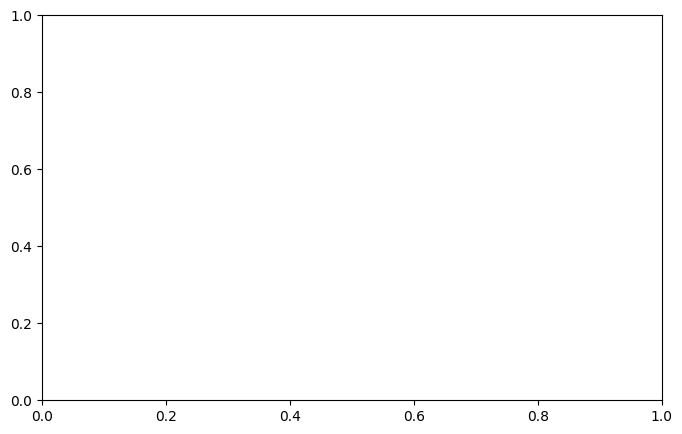

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))

times_position = hmp.utils.event_times(
    estimates,
    duration=False,
    mean=False,
    add_stim=True
)

baseline = -0.1 * sfreq
n_samples = 0.6 * sfreq

event = 2  
channel_subset = ['E5', 'E6', 'E7', 'E12', 'E13', 'E106', 'E112']

for cond in ["RECOG_TARGET","RECOG_LURE"]:

    subset = (
        epoch_data
        .where(epoch_data.trial_type == cond, drop=True)
        .stack(trial=["participant","epoch"])
        .data
        .dropna("trial", how="all")
    )

    centered = hmp.utils.centered_activity(
        subset,
        times_position,
        channel_subset,
        event=event,
        n_samples=n_samples,
        baseline=baseline
    )

    centered = centered.data.unstack().mean("channel")

    indiv = centered.groupby("participant").mean("epoch")

    mean_tc = indiv.mean("participant")
    std_tc = indiv.std("participant")

    ax.plot(centered.sample, mean_tc, label=cond)
    ax.fill_between(
        centered.sample,
        mean_tc-std_tc,
        mean_tc+std_tc,
        alpha=.2
    )

ax.set_title("FN400")
ax.legend()

## LPC

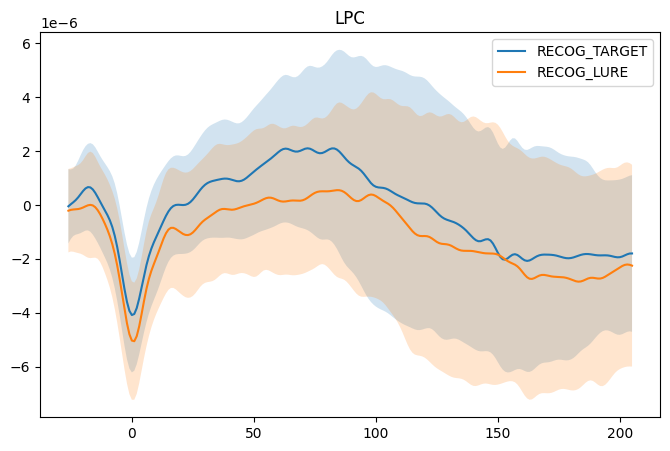

In [28]:
fig, ax = plt.subplots(figsize=(8,5))

times_position = hmp.utils.event_times(
    estimates,
    duration=False,
    mean=False,
    add_stim=True
)

baseline = -0.1 * sfreq
n_samples = 0.8 * sfreq

event = 3 
channel_subset = ['E52', 'E53', 'E54', 'E60', 'E61', 'E62', 'E67', 'E72', 'E77', 'E79']

for cond in ["RECOG_TARGET","RECOG_LURE"]:

    subset = (
        epoch_data
        .where(epoch_data.trial_type == cond, drop=True)
        .stack(trial=["participant","epoch"])
        .data
        .dropna("trial", how="all")
    )

    centered = hmp.utils.centered_activity(
        subset,
        times_position,
        channel_subset,
        event=event,
        n_samples=n_samples,
        baseline=baseline
    )

    centered = centered.data.unstack().mean("channel")

    indiv = centered.groupby("participant").mean("epoch")

    mean_tc = indiv.mean("participant")
    std_tc = indiv.std("participant")

    ax.plot(centered.sample, mean_tc, label=cond)
    ax.fill_between(
        centered.sample,
        mean_tc-std_tc,
        mean_tc+std_tc,
        alpha=.2
    )

ax.set_title("LPC")
ax.legend()

In [10]:
import numpy as np
import pandas as pd


# =====================================================
# Inspecteer estimates
# =====================================================

print(estimates)
print(estimates.dims)
print(estimates.shape)

<xarray.DataArray (trial: 4078, sample: 510, event: 5)> Size: 83MB
array([[[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.02599595, 0.        , 0.        , 0.        , 0.        ],
        [0.04164882, 0.        , 0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.00837791, 0.        , 0.        , 0.        , 0.        ],
        [0.01611513, 0.        , 0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        , 0.        , 0.    

In [11]:
import numpy as np
import pandas as pd


# =====================================================
# HMP single-trial latencies
# =====================================================

# xarray -> numpy
est = estimates.values


n_trials = est.shape[0]
n_events = est.shape[2]


hmp_features = []


for trial in range(n_trials):

    row = {
        "trial": trial,
        "condition": estimates.trial_type.values[trial],
        "participant": estimates.participant.values[trial],
        "RT": estimates.RT.values[trial],
        "correct": estimates.correct.values[trial]
    }


    for event in range(n_events):

        # probability curve van dit event
        prob = est[trial, :, event]


        # sample met hoogste probability
        peak_sample = np.argmax(prob)


        # sample naar ms
        latency_ms = (
            peak_sample / estimates.sfreq
        ) * 1000


        row[
            f"event_{event+1}_latency"
        ] = latency_ms


        # optioneel: maximale zekerheid van event
        row[
            f"event_{event+1}_prob"
        ] = np.max(prob)



    hmp_features.append(row)



# dataframe
hmp_features = pd.DataFrame(
    hmp_features
)


hmp_features.head()

,trial,condition,participant,RT,correct,event_1_latency,event_1_prob,event_2_latency,event_2_prob,event_3_latency,event_3_prob,event_4_latency,event_4_prob,event_5_latency,event_5_prob
0,0,RECOG_LURE,sub-LTP063_ses-0_epo,1.856,1.0,46.87500,0.086071,148.43750,0.055717,328.12500,0.013099,1710.93750,0.022305,1832.03125,0.101649
1,1,RECOG_LURE,sub-LTP063_ses-0_epo,1.316,1.0,54.68750,0.069422,164.06250,0.084725,519.53125,0.017026,1167.96875,0.035042,1296.87500,0.066100
2,2,RECOG_LURE,sub-LTP063_ses-0_epo,1.524,1.0,35.15625,0.056386,167.96875,0.030523,531.25000,0.025940,1367.18750,0.027376,1437.50000,0.071381
3,3,RECOG_LURE,sub-LTP063_ses-0_epo,1.468,1.0,27.34375,0.044512,171.87500,0.024579,601.56250,0.021135,1328.12500,0.024110,1437.50000,0.053417
4,4,RECOG_LURE,sub-LTP063_ses-0_epo,1.352,1.0,35.15625,0.059411,339.84375,0.047445,558.59375,0.022002,1226.56250,0.020813,1261.71875,0.066287


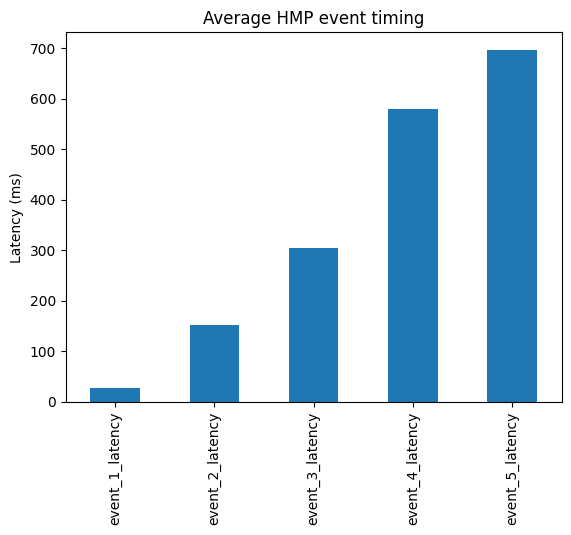

In [12]:
import matplotlib.pyplot as plt


lat_cols = [
    "event_1_latency",
    "event_2_latency",
    "event_3_latency",
    "event_4_latency",
    "event_5_latency"
]


hmp_features[lat_cols].mean().plot(
    kind="bar"
)

plt.ylabel(
    "Latency (ms)"
)

plt.title(
    "Average HMP event timing"
)

plt.show()

## for classifier

In [ ]:
fn400 = hmp_features[
    "event_2_latency"
]


lpc = hmp_features[
    "event_3_latency"
]

X = hmp_features[
[
"event_1_latency",
"event_2_latency",
"event_3_latency",
"event_4_latency",
"event_5_latency"
]
]


y = hmp_features[
"condition"
]